# Aula 02 — Outliers, Normalização e Transformações de Dados

**Semana 06 · Dia 02 (Quinta-feira) · SENAI — Visualização de Dados**

Na aula anterior tratamos missings e duplicatas. Hoje vamos nos aprofundar em outros três pilares da limpeza e preparação de dados:

1. **Outliers** — valores extremos que fogem do padrão e podem distorcer análises
2. **Normalização** — deixar colunas numéricas na mesma escala para comparação justa
3. **Transformações** — criar novas colunas a partir das existentes usando funções, condições e categorias

Continuaremos com a **base de vendas do supermercado**, mas vamos enriquecê-la com dados "sujos" para praticar.

## Bloco 0 — Setup

Carregamos a base e criamos a versão suja da aula anterior.
Dessa vez, também vamos inserir **outliers** — valores de vendas absurdamente altos ou baixos que simulam erros de digitação.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

# Limpa a base (repete o pipeline da aula 01)
df_limpo = df.copy()

# Inserindo outliers manualmente para prática
np.random.seed(99)
df_outlier = df_limpo.copy()

# Simula erros de digitação: preços absurdos e quantidades inválidas
idx_preco_alto  = np.random.choice(df_outlier.index, 4, replace=False)
idx_preco_baixo = np.random.choice(df_outlier.index, 3, replace=False)
idx_qtd_alta    = np.random.choice(df_outlier.index, 3, replace=False)

df_outlier.loc[idx_preco_alto,  'Valor Líquido'] = [850.0, 1200.0, 980.0, 760.0]   # preços 10x acima
df_outlier.loc[idx_preco_baixo, 'Valor Líquido'] = [0.50, 0.30, 0.10]               # preços impossíveis
df_outlier.loc[idx_qtd_alta,    'Quantidade']    = [50, 80, 120]                     # quantidades impossíveis

print(f"Dataset com outliers: {df_outlier.shape}")
print(f"Valor Líquido: min={df_outlier['Valor Líquido'].min():.2f} | max={df_outlier['Valor Líquido'].max():.2f}")
print(f"Quantidade: min={df_outlier['Quantidade'].min()} | max={df_outlier['Quantidade'].max()}")

Dataset com outliers: (250, 12)
Valor Líquido: min=0.10 | max=1200.00
Quantidade: min=1 | max=120


C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


## Bloco 1 — Outliers: O Que São e Por Que Importam

### O que é um outlier?

Um **outlier** é um valor que se afasta muito dos outros — pode ser:
- **Erro de digitação** → alguém digitou R$ 850 em vez de R$ 8,50
- **Erro de sistema** → bug que multiplicou o valor por 100
- **Evento real mas excepcional** → venda de final de ano que foi 10x a média

### Por que outliers são um problema?

Eles **distorcem estatísticas**. Se um produto custou R$ 1.200 por erro de digitação:
- A **média** sobe e não representa mais a realidade
- A **correlação** entre variáveis pode ser completamente alterada
- Modelos de machine learning podem ser enganados

### Como detectar?

Existem dois métodos principais:
1. **Boxplot visual** — vê os outliers nos "bigodes" do gráfico
2. **IQR (Interquartile Range)** — método estatístico objetivo

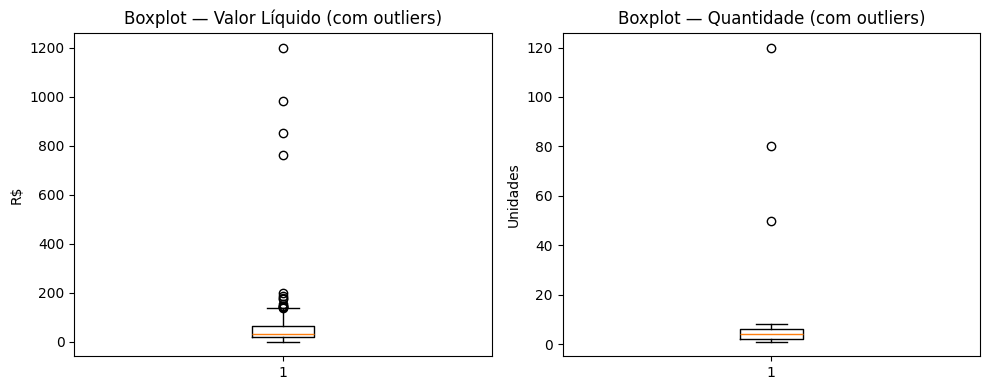

In [3]:
# Boxplot: visualização mais intuitiva de outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Valor Líquido
axes[0].boxplot(df_outlier['Valor Líquido'], vert=True)
axes[0].set_title('Boxplot — Valor Líquido (com outliers)')
axes[0].set_ylabel('R$')

# Quantidade
axes[1].boxplot(df_outlier['Quantidade'], vert=True)
axes[1].set_title('Boxplot — Quantidade (com outliers)')
axes[1].set_ylabel('Unidades')

plt.tight_layout()
plt.show()

---
### Como ler um Boxplot?

```
         │
    ┌────┴────┐   ← Q3 (75° percentil)
    │         │
    │  ─────  │   ← Mediana (Q2 / 50°)
    │         │
    └────┬────┘   ← Q1 (25° percentil)
         │
    ○ ○ ○        ← Outliers (pontos fora dos bigodes)
```

- A **caixa** contém 50% dos dados (entre Q1 e Q3)
- Os **bigodes** se estendem até 1,5× o IQR (Interquartile Range)
- **Pontos fora dos bigodes** → outliers

### IQR = Q3 - Q1

Quanto maior o IQR, mais "espalhados" estão os dados centrais.

### Método IQR: Detectando Outliers Estatisticamente

O método IQR define limites objetivos para "normal":

```
Limite inferior = Q1 - 1.5 × IQR
Limite superior = Q3 + 1.5 × IQR

Qualquer valor fora desses limites é considerado outlier.
```

Esse é exatamente o critério que o boxplot usa para desenhar os bigodes e marcar os pontos fora.

In [4]:
# Calculando outliers com IQR para 'Valor Líquido'
Q1 = df_outlier['Valor Líquido'].quantile(0.25)
Q3 = df_outlier['Valor Líquido'].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print(f"Q1 (25°)        : R$ {Q1:.2f}")
print(f"Q3 (75°)        : R$ {Q3:.2f}")
print(f"IQR (Q3 - Q1)   : R$ {IQR:.2f}")
print(f"Limite inferior : R$ {limite_inf:.2f}")
print(f"Limite superior : R$ {limite_sup:.2f}")
print()

# Quais linhas são outliers?
mask_outlier = (df_outlier['Valor Líquido'] < limite_inf) | (df_outlier['Valor Líquido'] > limite_sup)
print(f"Outliers detectados: {mask_outlier.sum()} linhas")
print()
print("Valores outliers:")
print(df_outlier.loc[mask_outlier, ['Data', 'Produto', 'Quantidade', 'Valor Líquido']].to_string())

Q1 (25°)        : R$ 16.99
Q3 (75°)        : R$ 64.56
IQR (Q3 - Q1)   : R$ 47.58
Limite inferior : R$ -54.38
Limite superior : R$ 135.93

Outliers detectados: 14 linhas

Valores outliers:
          Data                   Produto  Quantidade  Valor Líquido
19  2026-02-15             Shampoo 350ml           8         136.80
22  2026-03-04  Papel Higiênico 12 rolos           7         173.53
40  2026-01-01             Shampoo 350ml           7         760.00
47  2026-02-28     Queijo Mussarela 500g           6         146.72
75  2026-01-21                 Café 500g           8         142.06
105 2026-02-28     Queijo Mussarela 500g           7         176.82
117 2026-01-17                 Café 500g           7         141.03
123 2026-04-08     Queijo Mussarela 500g           7         186.90
153 2026-04-26                 Arroz 5kg           5         143.35
171 2026-01-26     Queijo Mussarela 500g           8         850.00
192 2026-03-30  Papel Higiênico 12 rolos           8         197

### Tratando Outliers: Três Abordagens

1. **Remover** (`dropna` / boolean mask) — quando o erro é certamente um erro
2. **Substituir pela mediana** — quando não quer perder a linha, mas quer um valor razoável
3. **Capping** — substitui por um limite máximo/mínimo (menos agressivo que remover)

> **Regra de ouro:** antes de remover, entenda o porquê do outlier. Um R$ 197 pode ser legítimo (venda grande de carne); um R$ 1.200 quase certamente é erro de digitação para a nossa base.

In [5]:
# Abordagem 1: Remover outliers
df_sem_outlier = df_outlier[~mask_outlier].copy()
print(f"Após remover outliers: {len(df_sem_outlier)} linhas (removidas {mask_outlier.sum()})")

# Abordagem 2: Capping — substituir pelo limite
df_capped = df_outlier.copy()
df_capped['Valor Líquido'] = df_capped['Valor Líquido'].clip(lower=limite_inf, upper=limite_sup)
print(f"Após capping: máximo = R$ {df_capped['Valor Líquido'].max():.2f}")

# Comparação das médias
print()
print(f"{'Versão':<30} {'Média Valor Líquido':>20}")
print("-" * 52)
print(f"{'Com outliers':<30} R$ {df_outlier['Valor Líquido'].mean():>16.2f}")
print(f"{'Sem outliers (removido)':<30} R$ {df_sem_outlier['Valor Líquido'].mean():>16.2f}")
print(f"{'Com capping':<30} R$ {df_capped['Valor Líquido'].mean():>16.2f}")
print(f"{'Mediana (referência)':<30} R$ {df_outlier['Valor Líquido'].median():>16.2f}")

Após remover outliers: 236 linhas (removidas 14)
Após capping: máximo = R$ 135.93

Versão                          Média Valor Líquido
----------------------------------------------------
Com outliers                   R$            59.32
Sem outliers (removido)        R$            40.02
Com capping                    R$            45.39
Mediana (referência)           R$            32.02


## Bloco 2 — Normalização: Deixando os Dados na Mesma Escala

### Por que normalizar?

Imagine comparar **Quantidade** (1–8 unidades) com **Valor Líquido** (R$ 3 a R$ 200).
Se você somar ou comparar diretamente, o Valor vai "dominar" por ter escala maior.

Normalização resolve isso: transforma todas as colunas para **a mesma faixa de valores**.

### Dois métodos principais:

| Método | Fórmula | Resultado | Quando usar |
|---|---|---|---|
| **Min-Max** | `(x - min) / (max - min)` | Valores entre 0 e 1 | Quando sabe os limites do dado |
| **Z-Score** | `(x - média) / desvio_padrão` | Média=0, Desvio=1 | Quando quer neutralizar a escala completamente |

In [6]:
# Normalizando com Min-Max (sem sklearn — só pandas/numpy)
df_norm = df_sem_outlier.copy()

colunas_numericas = ['Quantidade', 'Preço Unitário', 'Desconto %', 'Valor Líquido']

for col in colunas_numericas:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    df_norm[col + '_norm'] = (df_norm[col] - min_val) / (max_val - min_val)

print("Estatísticas após normalização Min-Max (intervalo 0–1):")
cols_norm = [c + '_norm' for c in colunas_numericas]
print(df_norm[cols_norm].describe().round(3).to_string())

Estatísticas após normalização Min-Max (intervalo 0–1):
       Quantidade_norm  Preço Unitário_norm  Desconto %_norm  Valor Líquido_norm
count          236.000              236.000          236.000             236.000
mean             0.033                0.205            0.388               0.295
std              0.082                0.177            0.366               0.235
min              0.000                0.000            0.000               0.000
25%              0.008                0.076            0.000               0.122
50%              0.025                0.143            0.300               0.224
75%              0.042                0.312            0.700               0.445
max              1.000                1.000            1.000               1.000


In [7]:
# Normalizando com Z-Score
df_zscore = df_sem_outlier.copy()

for col in ['Quantidade', 'Preço Unitário', 'Valor Líquido']:
    media = df_zscore[col].mean()
    desvio = df_zscore[col].std()
    df_zscore[col + '_z'] = (df_zscore[col] - media) / desvio

print("Estatísticas após Z-Score (média≈0, desvio≈1):")
cols_z = ['Quantidade_z', 'Preço Unitário_z', 'Valor Líquido_z']
print(df_zscore[cols_z].describe().round(3).to_string())

Estatísticas após Z-Score (média≈0, desvio≈1):
       Quantidade_z  Preço Unitário_z  Valor Líquido_z
count       236.000           236.000          236.000
mean          0.000             0.000           -0.000
std           1.000             1.000            1.000
min          -0.397            -1.161           -1.257
25%          -0.295            -0.730           -0.738
50%          -0.089            -0.354           -0.304
75%           0.116             0.605            0.635
max          11.803             4.490            2.999


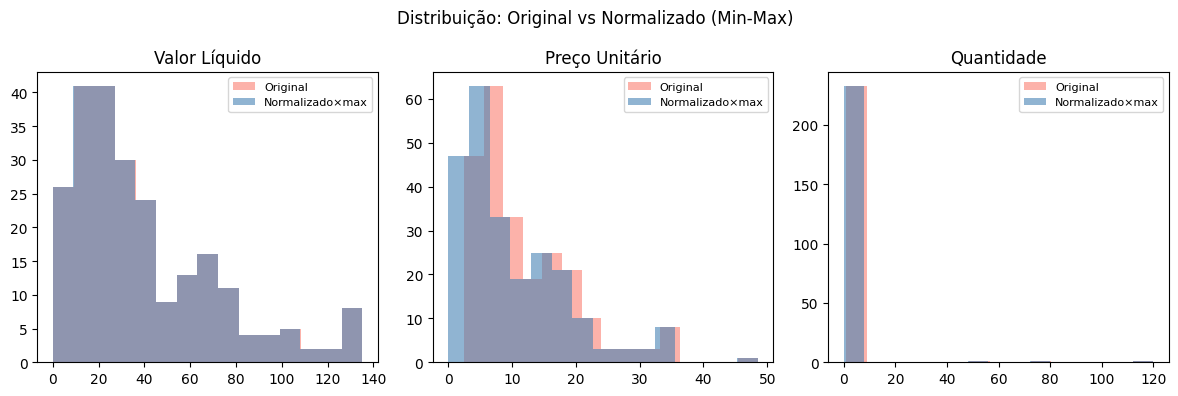

In [8]:
# Comparação visual: original vs normalizado
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ['Valor Líquido', 'Preço Unitário', 'Quantidade']):
    ax.hist(df_sem_outlier[col], bins=15, color='salmon', alpha=0.6, label='Original')
    ax.hist(df_norm[col + '_norm'] * df_sem_outlier[col].max(), bins=15,
            color='steelblue', alpha=0.6, label='Normalizado×max')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição: Original vs Normalizado (Min-Max)')
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

A forma das distribuições **não muda** com a normalização — apenas a escala do eixo X muda. Isso é esperado: normalizar não "inventa" dados, apenas os reescala.

### Por que isso importa?

- **Comparação de produtos** com preços e quantidades muito diferentes fica justa
- **Algoritmos de machine learning** (que vêm mais à frente na carreira) requerem dados normalizados
- Alguns gráficos (como heatmaps de correlação) ficam mais interpretáveis com dados na mesma escala

## Bloco 3 — Transformações: Criando Novas Colunas

### Por que criar colunas novas?

Raramente os dados chegam exatamente no formato que precisamos para análise. Precisamos:
- Extrair o **mês** de uma coluna de data
- Calcular a **margem de lucro** a partir de custo e receita
- Categorizar clientes em **faixas de gasto**
- Limpar e padronizar textos

Existem três ferramentas principais para isso:

| Ferramenta | Para que serve |
|---|---|
| `.apply(função)` | Aplicar qualquer função a cada linha/coluna |
| `pd.cut()` | Dividir valores numéricos em faixas (bins) |
| `np.where()` / `np.select()` | Transformações condicionais (if/else vetorizados) |

### `apply()`: Aplicando Funções Personalizadas

`apply()` aplica uma função a cada **elemento** (axis padrão=0 para linhas, axis=1 para colunas).

Dois formatos comuns:
1. **Lambda** → função de uma linha, descartável
2. **Função nomeada** → quando a lógica é mais complexa

In [9]:
df_transf = df_sem_outlier.copy()

# Exemplo 1: extrair mês e dia da semana da coluna Data
df_transf['Mês']          = df_transf['Data'].dt.month
df_transf['Nome_Mês']     = df_transf['Data'].dt.strftime('%B')
df_transf['Dia_Semana']   = df_transf['Data'].dt.day_name()

# Exemplo 2: padronizar texto com lambda
df_transf['Loja_Upper'] = df_transf['Loja'].apply(lambda x: x.upper())

# Exemplo 3: função personalizada (classificar tamanho da compra)
def tamanho_compra(valor):
    if valor < 20:
        return 'Pequena'
    elif valor < 60:
        return 'Média'
    else:
        return 'Grande'

df_transf['Tamanho_Compra'] = df_transf['Valor Líquido'].apply(tamanho_compra)

print(df_transf[['Data', 'Nome_Mês', 'Dia_Semana', 'Valor Líquido', 'Tamanho_Compra']].head(8).to_string(index=False))

      Data Nome_Mês Dia_Semana  Valor Líquido Tamanho_Compra
2026-01-04  January     Sunday          94.12         Grande
2026-01-04  January     Sunday          27.88          Média
2026-02-27 February     Friday          61.46         Grande
2026-01-12  January     Monday          36.14          Média
2026-05-05      May    Tuesday         126.49         Grande
2026-04-09    April   Thursday          14.15        Pequena
2026-01-27  January    Tuesday          17.31        Pequena
2026-03-29    March     Sunday          15.74        Pequena


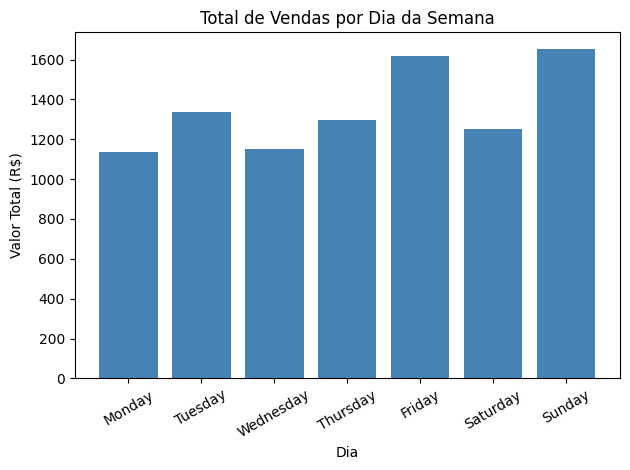

In [10]:
# Vendas por dia da semana
vendas_dia = df_transf.groupby('Dia_Semana')['Valor Líquido'].sum()

# Ordenar pelos dias da semana corretamente
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
vendas_dia = vendas_dia.reindex([d for d in ordem_dias if d in vendas_dia.index])

plt.bar(vendas_dia.index, vendas_dia.values, color='steelblue')
plt.title('Total de Vendas por Dia da Semana')
plt.xlabel('Dia')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### `pd.cut()`: Criando Faixas de Valores

`pd.cut()` divide uma coluna numérica em **intervalos definidos por você**, atribuindo um rótulo a cada faixa.

Muito útil para:
- Faixas de preço (`'Barato'`, `'Médio'`, `'Caro'`)
- Faixas de quantidade
- Segmentação de clientes por valor de compra

```python
pd.cut(serie, bins=[limites], labels=['rótulos'])
```
O número de rótulos deve ser igual ao número de intervalos (= len(bins) - 1).

In [11]:
# Faixas de valor líquido da compra
bins_valor  = [0, 20, 60, 120, 300]
labels_valor = ['Ticket Baixo', 'Ticket Médio', 'Ticket Alto', 'Ticket Premium']

df_transf['Faixa_Ticket'] = pd.cut(
    df_transf['Valor Líquido'],
    bins=bins_valor,
    labels=labels_valor,
    right=True    # intervalos fechados à direita: (0,20]
)

print("Distribuição de Faixas de Ticket:")
print(df_transf['Faixa_Ticket'].value_counts().sort_index().to_string())

print()
print("Ticket médio por categoria:")
print(df_transf.groupby('Faixa_Ticket', observed=True)['Valor Líquido'].mean().round(2).to_string())

Distribuição de Faixas de Ticket:
Faixa_Ticket
Ticket Baixo      77
Ticket Médio      99
Ticket Alto       51
Ticket Premium     9

Ticket médio por categoria:
Faixa_Ticket
Ticket Baixo       11.93
Ticket Médio       33.94
Ticket Alto        78.42
Ticket Premium    129.60


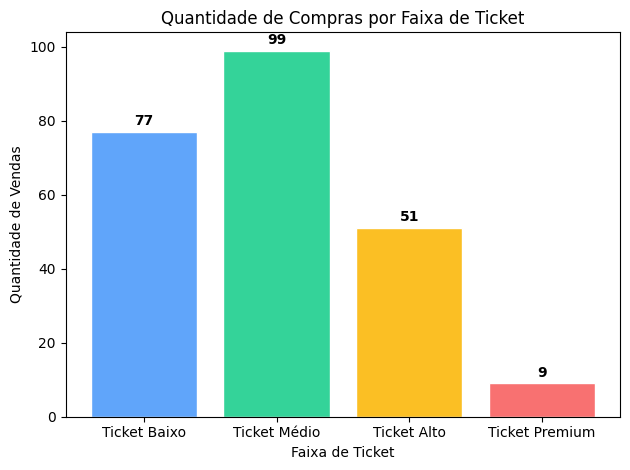

In [12]:
faixas = df_transf['Faixa_Ticket'].value_counts().sort_index()
cores  = ['#60a5fa', '#34d399', '#fbbf24', '#f87171']

plt.bar(faixas.index, faixas.values, color=cores, edgecolor='white')
for i, v in enumerate(faixas.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

plt.title('Quantidade de Compras por Faixa de Ticket')
plt.xlabel('Faixa de Ticket')
plt.ylabel('Quantidade de Vendas')
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?

A distribuição das vendas por faixa de valor — quantas compras foram "pequenas" (Ticket Baixo) e quantas foram expressivas (Ticket Premium).

### Por que isso importa?

Segmentar por ticket é uma das análises mais usadas em varejo:
- Concentração em ticket baixo pode indicar clientes do tipo "compra rápida"
- Poucos tickets premium podem ser vendas para empresas (B2B)
- Essa segmentação pode guiar estratégias de promoção e mix de produtos

### `np.where()` e `np.select()`: Condições Vetorizadas

`np.where(condição, valor_se_true, valor_se_false)` é o `if/else` do NumPy.
`np.select(lista_condições, lista_escolhas, default)` para múltiplas condições.

São muito mais rápidos que `apply()` com `if/elif/else` — especialmente em bases grandes.

In [13]:
# np.where: coluna binária (tem desconto ou não?)
df_transf['Tem_Desconto'] = np.where(df_transf['Desconto %'] > 0, 'Sim', 'Não')

# np.select: classificar tipo de cliente por comportamento
condicoes = [
    df_transf['Cliente'] == 'Clube Fidelidade',
    df_transf['Cliente'] == 'Empresa',
    df_transf['Cliente'] == 'Delivery',
]
categorias = ['Fiel', 'Corporativo', 'Digital']

df_transf['Perfil_Cliente'] = np.select(condicoes, categorias, default='Avulso')

print("Perfil de Cliente por tipo:")
print(df_transf['Perfil_Cliente'].value_counts().to_string())

print()
print("Vendas com desconto vs sem desconto:")
print(df_transf['Tem_Desconto'].value_counts().to_string())

Perfil de Cliente por tipo:
Perfil_Cliente
Corporativo    75
Fiel           57
Digital        54
Avulso         50

Vendas com desconto vs sem desconto:
Tem_Desconto
Sim    161
Não     75


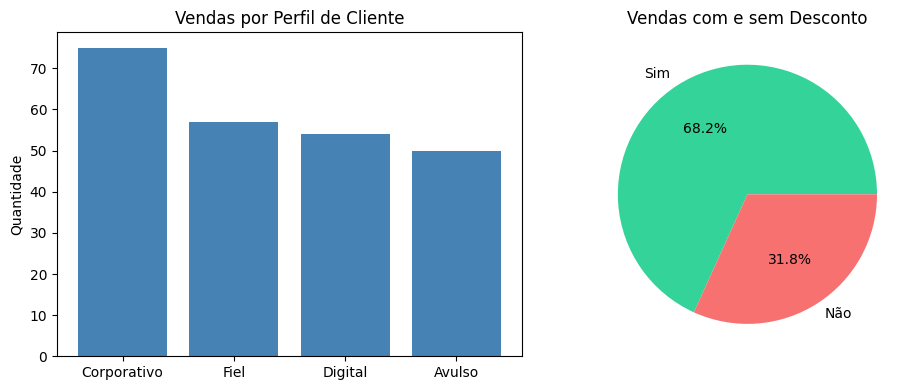

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Perfil de cliente
perfil = df_transf['Perfil_Cliente'].value_counts()
axes[0].bar(perfil.index, perfil.values, color='steelblue')
axes[0].set_title('Vendas por Perfil de Cliente')
axes[0].set_ylabel('Quantidade')

# Desconto
desc = df_transf['Tem_Desconto'].value_counts()
axes[1].pie(desc.values, labels=desc.index, autopct='%1.1f%%',
            colors=['#34d399', '#f87171'])
axes[1].set_title('Vendas com e sem Desconto')

plt.tight_layout()
plt.show()

## Exercício Prático — Aula 02

Use o `df_outlier` e `df_sem_outlier` criados nesta aula:

1. **Outliers em Quantidade**: usando o método IQR, detecte e liste os outliers da coluna `'Quantidade'`. Quantos são?

2. **Z-Score manual**: normalize a coluna `'Preço Unitário'` usando Z-Score. Verifique que a média resultante é ≈ 0 e o desvio padrão ≈ 1.

3. **apply() com lógica**: crie a coluna `'Horário_Venda'` a partir da coluna `'Data'`, classificando:
   - Hora < 12 → `'Manhã'`
   - Hora < 18 → `'Tarde'`
   - Caso contrário → `'Noite'`
   Dica: use `df['Data'].dt.hour`.

4. **pd.cut() com quantis**: use `pd.qcut()` (em vez de `pd.cut()`) para dividir `'Valor Líquido'` em 4 quartis iguais. Qual a diferença entre `cut` e `qcut`?

5. **Gráfico**: plote um gráfico de barras mostrando a **soma do Valor Líquido por Categoria**, com as barras ordenadas do maior para o menor.

## Gabarito — Pontos Principais

### Exercício 1 — Outliers em Quantidade
```python
Q1 = df_outlier['Quantidade'].quantile(0.25)
Q3 = df_outlier['Quantidade'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
outliers_qtd = df_outlier[df_outlier['Quantidade'] > limite_sup]
print(f"Outliers em Quantidade: {len(outliers_qtd)}")
```

### Exercício 3 — apply() com horário
```python
# Como 'Data' é datetime sem hora, hora sempre será 0
# Para simular: df['Data'].dt.hour
# Mas se todas forem 0, o resultado será 'Manhã' para todas
```

### Exercício 4 — Diferença cut vs qcut
```python
# pd.cut()  → bins com largura IGUAL (divide o intervalo igualmente)
# pd.qcut() → bins com FREQUÊNCIA IGUAL (cada bin tem mesma qtd de registros)
df_sem_outlier['Quartil'] = pd.qcut(df_sem_outlier['Valor Líquido'], q=4,
                                    labels=['Q1','Q2','Q3','Q4'])
print(df_sem_outlier['Quartil'].value_counts().sort_index())
```

### Exercício 5 — Soma por Categoria
```python
vendas_cat = df_sem_outlier.groupby('Categoria')['Valor Líquido'].sum().sort_values(ascending=False)
plt.barh(vendas_cat.index, vendas_cat.values, color='steelblue')
plt.title('Total de Vendas por Categoria')
plt.xlabel('Valor Total (R$)')
plt.tight_layout()
plt.show()
```

## Observações Finais

Hoje você aprendeu:

- **Boxplot** → visualização imediata de outliers
- **IQR** → método estatístico objetivo para detectar outliers
- **Capping** → `clip(lower, upper)` substitui sem remover linhas
- **Min-Max** → escala 0 a 1, preserva a distribuição
- **Z-Score** → centraliza em 0, unidade em desvio padrão
- `apply()` → flexível para qualquer função
- `pd.cut()` → bins com largura definida; `pd.qcut()` → bins com frequência igual
- `np.where()` / `np.select()` → if/else vetorizado, muito mais rápido que apply

---
**Na próxima aula (sexta-feira — revisão):** vamos aprender a **juntar bases de dados** com `concat` e `merge`, e construir um **pipeline completo** de limpeza do zero.